# Satellite melt rate distribution compared to MITgcm PIG melt 

For Fig D1

Satellite data: 
- Adusumilli et al. (2020) paper: https://www.nature.com/articles/s41561-020-0616-z data: https://library.ucsd.edu/dc/collection/bb0175934d github: https://github.com/sioglaciology/ice_shelf_change
- Zinck et al. (2024), paper in review: https://www.researchsquare.com/article/rs-4806463/v1 data: https://data.4tu.nl/datasets/4e2ba9a9-7b1b-4837-b52d-036f8c876e67
- Bedmachine, Morlighem et al. (2020) data: https://nsidc.org/data/nsidc-0756/versions/3  paper: https://www.nature.com/articles/s41561-019-0510-8





In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import scipy.io as sio
from MITgcmutils import mds

rho_ow = 1028
rho_ice = 917

paired = sns.color_palette("Paired", 10)

from dask.distributed import Client
import cmocean as cm
import cmcrameri

import cartopy.crs as ccrs
import matplotlib.pyplot as plt

import pyproj as proj4
from pyproj import Transformer

import xarray as xr
import xesmf as xe


In [2]:
# open polar projection used for all of these products
epsg4326 = proj4.CRS.from_epsg(4326) # Lat Lon WGS84
epsg3031 = proj4.CRS.from_epsg(3031) # SouthPolarStereo WGS84

#transformer = Transformer.from_crs(epsg4326, epsg3031)
transformer = Transformer.from_crs( epsg3031,epsg4326)


In [3]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35557,Workers: 7
Dashboard: /proxy/8787/status,Total threads: 14
Started: Just now,Total memory: 63.00 GiB
Comm: tcp://127.0.0.1:35601,Total threads: 2
Dashboard: /proxy/45111/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:38249,


In [13]:
# Adusumilli data (tools to open from https://github.com/sioglaciology/ice_shelf_change
folder = '/g/data/x77/cy8964/satellite-meltrate/Adusumilli/'
filename =folder+'ANT_iceshelf_melt_rates_CS2_2010-2018_v0.h5'
is_wb = h5py.File(filename,'r')
filename =folder+'ice_shelf_change/data/figure_1/max_thermal_forcing_200-800.h5'
tf = h5py.File(filename,'r')
x_wb = np.array(is_wb['/x'])
y_wb = np.array(is_wb['/y'])
wb = np.array(is_wb['/w_b'])


In [5]:
# open bedmachine data
BedMachine = xr.open_dataset('/g/data/x77/cy8964/satellite-meltrate/Adusumilli/BedMachineAntarctica-v3.nc')
BedMachine

<xarray.Dataset> Size: 4GB
Dimensions:    (x: 13333, y: 13333)
Coordinates:
  * x          (x) int32 53kB -3333000 -3332500 -3332000 ... 3332500 3333000
  * y          (y) int32 53kB 3333000 3332500 3332000 ... -3332500 -3333000
Data variables:
    mapping    |S1 1B ...
    mask       (y, x) int8 178MB ...
    firn       (y, x) float32 711MB ...
    surface    (y, x) float32 711MB ...
    thickness  (y, x) float32 711MB ...
    bed        (y, x) float32 711MB ...
    errbed     (y, x) float32 711MB ...
    source     (y, x) int8 178MB ...
    dataid     (y, x) int8 178MB ...
    geoid      (y, x) int16 356MB ...
Attributes: (12/17)
    Conventions:                 CF-1.7
    Title:                       BedMachine Antarctica
    Author:                      Mathieu Morlighem
    version:                     03-Jun-2022 (v3.4)
    nx:                          13333.0
    ny:                          13333.0
    ...                          ...
    ymax:                        3333000
    spacing:                     500
    no_data:                     -9999.0
    license:                     No restrictions on access or use
    Data_citation:               Morlighem M. et al., (2019), Deep glacial tr...
    Notes:                       Data processed at the Department of Earth Sy...

# For Appendix satellite figure

Text(0.5, 1.0, 'Adusumilli 2020 Pine Island Glacier melt rate')

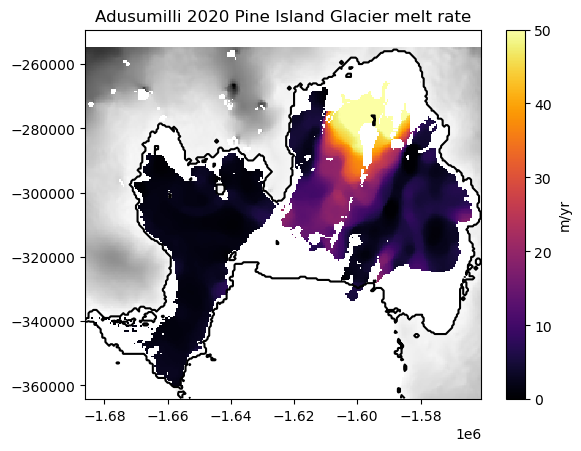

In [6]:
# plot together
wb_small = wb[4025:4250,2100:2351]
Wobs = wb_small
xs = x_wb[2100:2351]
ys = y_wb[4025:4250]

mask = BedMachine.mask.sel(x = slice(min(xs)[0],max(xs)[0]), y = slice(-255000,-364000))
surf = BedMachine.surface.sel(x = slice(min(xs)[0],max(xs)[0]), y = slice(-255000,-364000))

plt.pcolormesh(np.ravel(xs),np.ravel(ys),wb_small,vmin=0, vmax=50, cmap='inferno')
plt.colorbar(label = 'm/yr')

plt.contour(mask.x.values, mask.y.values,mask.values,levels = [2], colors = 'k')
plt.pcolormesh(mask.x.values, mask.y.values,surf.where(mask==2).values,cmap = 'Grays')


plt.title('Adusumilli 2020 Pine Island Glacier melt rate')

## open BURGEE data (Zinck 2024)

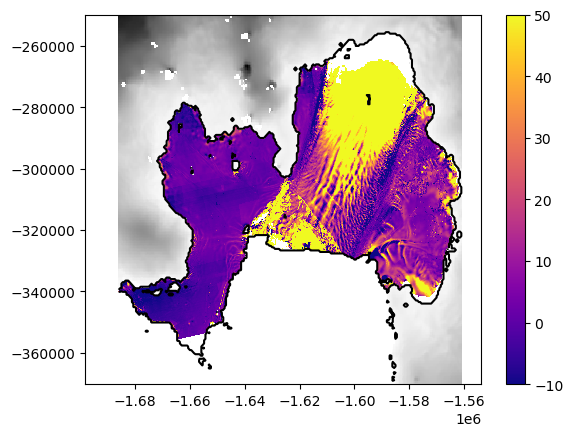

Text(0.5, 1.0, 'Distribution of melt rates, PIG (5m/yr bins)')

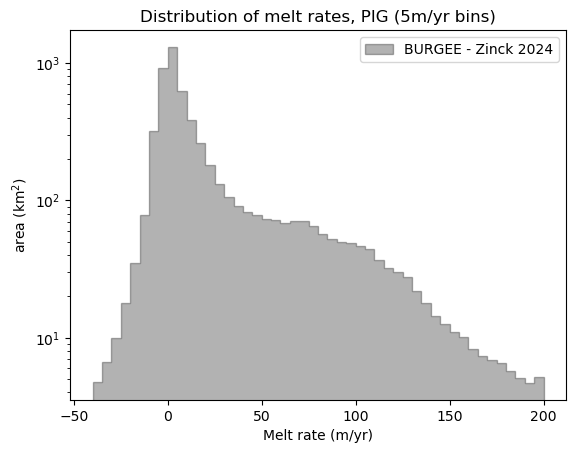

In [7]:
from osgeo import gdal   
  
dataset = gdal.Open('/g/data/x77/cy8964/satellite-meltrate/Adusumilli/PineIsland.tif')
ds = dataset
width = ds.RasterXSize
height = ds.RasterYSize
gt = ds.GetGeoTransform()
minx = gt[0]
miny = gt[3] + width*gt[4] + height*gt[5] 
maxx = gt[0] + width*gt[1] + height*gt[2]
maxy = gt[3] 

band1 = dataset.GetRasterBand(1)
b1 = dataset.ReadAsArray() 
img = b1
f = plt.figure() 
xs_arr = np.arange(img.shape[1])*(maxx-minx)/img.shape[1] + minx
ys_arr = np.arange(img.shape[0])*(maxy-miny)/img.shape[0] + miny

plt.pcolormesh(xs_arr,ys_arr,np.flip(img,axis = 0), cmap = 'plasma', vmin = -10, vmax = 50)
plt.colorbar()

mask = BedMachine.mask.sel(x = slice(min(xs)[0],max(xs)[0]), y = slice(-250000,-370000))
surf = BedMachine.surface.sel(x = slice(min(xs)[0],max(xs)[0]), y = slice(-250000,-370000))

plt.contour(mask.x.values, mask.y.values,mask.values,levels = [2], colors = 'k')
plt.pcolormesh(mask.x.values, mask.y.values,surf.where(mask==2).values,cmap = 'Grays')
plt.show() 

fig, axes = plt.subplots()
colors = 'k'
axes.hist(np.ravel(img), np.linspace(-40,200,49), weights = np.ones_like(np.ravel(img))*0.05**2,
          histtype='step', color=colors, fill = True, alpha = 0.3,
          label='BURGEE - Zinck 2024')
#axes.set_ylim(1,80000)
axes.set_ylabel('area (km$^2$)')
axes.set_yscale('log')
axes.set_xlabel('Melt rate (m/yr)')
axes.legend()
axes.set_title('Distribution of melt rates, PIG (5m/yr bins)')


# Plot MR histograms all together

In [8]:
#get MITgcm domain contour in Ant projection for plots
transformer = Transformer.from_crs( epsg4326,epsg3031)
dir = '/g/data/x77/cy8964/mitgcm/archive/'
names = 'original-run-R22_exe_tuned2'
W = xr.open_dataset(dir+names+'/'+names+'_days2050average.nc').melt.values
T = xr.open_dataset(dir+names+'/'+names+'_days2050average.nc').temp.values
XC = xr.open_dataset(dir+names+'/'+names+'_days2050average.nc').XC.values
YC = xr.open_dataset(dir+names+'/'+names+'_days2050average.nc').YC.values

xs = np.zeros_like(W)
ys = np.zeros_like(W)
for j in np.arange(len(YC[:,0])):
    for i in np.arange(len(XC[0,:])):
        xs[j,i],ys[j,i], = transformer.transform(YC[j,0],XC[0,i],)
ds_MITbdry = xr.Dataset(
    data_vars=dict(
        melt_rate=(["lat","lon"], W),
        temp=(["z","lat","lon"], T),
    ),
    coords=dict(
        x=(["y","x"], xs),
        y=(["y","x"], ys),
        lon=("x", XC[0,:]),
        lat=("y", YC[:,0]),
        z=("z",-np.arange(130)*10.0)),
    
    attrs=dict(description="Melt rate MITgcm mapped to antarctic proj"),
)


(225, 225)


/jobfs/145770218.gadi-pbs/ipykernel_3883516/271960059.py:71: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handle1 = patches.Patch(color=colors[0], alpha=0.5, linewidth=2, edgecolor = colors[0], label='Tuned HJ99-neutral')
/jobfs/145770218.gadi-pbs/ipykernel_3883516/271960059.py:72: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handle2 = patches.Patch(color=colors[1], alpha=0.5, linewidth=2, edgecolor = colors[0], label='Tuned StratFeedback')
/jobfs/145770218.gadi-pbs/ipykernel_3883516/271960059.py:73: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handle3 = patches.Patch(color=colors[2], alpha=0.5, linewidth=2, edgecolor = colors[0], label='Tuned StratFeedback + MK18')
/jobfs/145770218.gadi-pbs/ipykernel_3883516/271960059.py:74: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handle4 = p

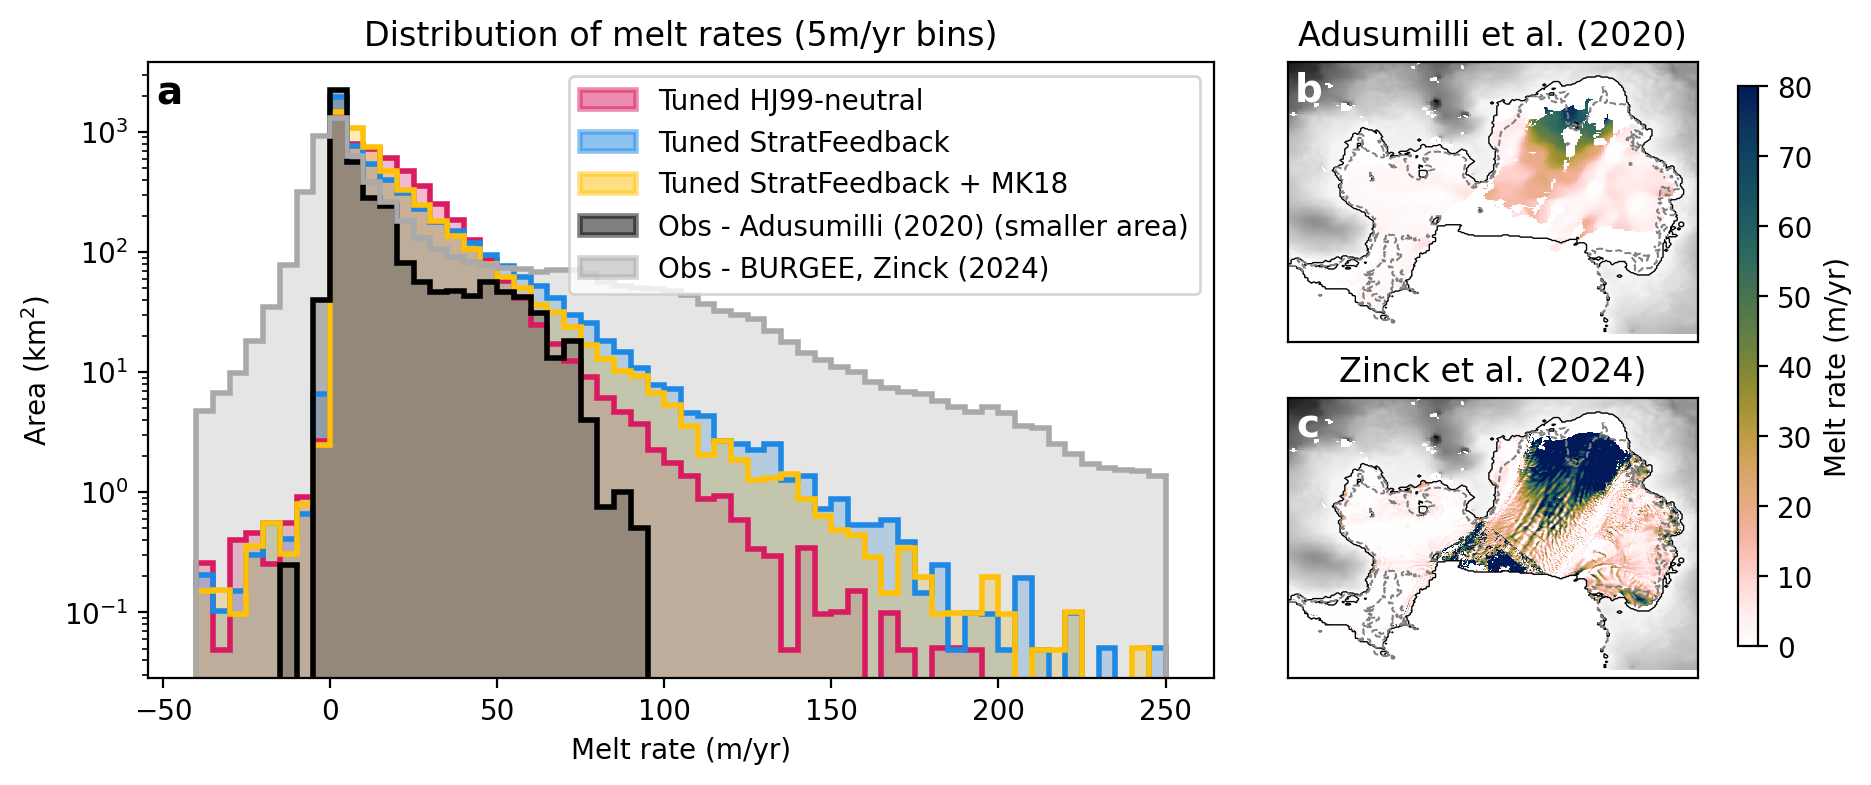

In [9]:
from MITgcmutils import mds
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import cmcrameri as cmc

Wobs = wb[4000:4225,2125:2350,]
print(Wobs.shape)
xs = x_wb[2125:2351]
ys = y_wb[4000:4226] #diffs are 500m
area = 500*500/1e6*(np.ones(len(Wobs.flatten())))


fig = plt.figure(figsize = (10,4),dpi = 200)
gs = gridspec.GridSpec(2, 2, width_ratios=[2.6,1])
a0 = fig.add_subplot(gs[:,0])
a1 = fig.add_subplot(gs[0,1])
a2 = fig.add_subplot(gs[1,1])

a = [a0,a1,a2]

axes = a[0]
dir = '/g/data/x77/cy8964/mitgcm/archive/'
names = ['original-run-R22_exe_tuned2','run-R22-bigCd-20Aug-tuned3','run-R22-MK18limlocal-tuned3']
titles = ['HJ99-neutral', 'StratFeedback', 'StratFeedback + MK18']
#end = '/output001/'
# melt in kg/m^2/s to m/yr = multiply by #seconds per year, divide by rho_0
s_to_yr = 3600*24*365
rho0 = 1030
WHJ99 = xr.open_dataset(dir+names[0]+'/'+names[0]+'_days2050average.nc').melt.values
WR22 = xr.open_dataset(dir+names[1]+'/'+names[1]+'_days2050average.nc').melt.values
WR22mk = xr.open_dataset(dir+names[2]+'/'+names[2]+'_days2050average.nc').melt.values

WHJ99 = (np.where(WHJ99!=0, WHJ99,np.nan)*(-s_to_yr)/rho0).flatten()
WR22 = (np.where(WR22!=0, WR22,np.nan)*(-s_to_yr)/rho0).flatten()
WR22mk = (np.where(WR22mk!=0, WR22mk,np.nan)*(-s_to_yr)/rho0).flatten()

Area = xr.open_dataset(dir+names[0]+'/'+names[0]+'_days2050average.nc').RAC.values/1e6
Area = Area.flatten()


axes.set_ylabel('Area (km$^2$)')
colors = ['#D81B60', '#1E88E5', '#FFC107','#000000','darkgrey']#'#9F53E9']
# axes.hist([WHJ99,WR22cd,WR22,Wobs.flatten()], np.linspace(-40,200,49), weights = [Area,Area,Area,area],
#           histtype='step', alpha = 0.4, edgecolors = colors,color=colors, fill = True,
#           label=['HJ99 original', 'R22 + tuned Cd', 'R22 strat. feedback','Adusumilli (2020)'])
axes.hist(WHJ99, np.linspace(-40,250,59), weights = Area,
          histtype='stepfilled', color=colors[0], alpha = 0.3, linewidth = 2)
axes.hist(WR22, np.linspace(-40,250,59), weights = Area,
          histtype='stepfilled',  color=colors[1],alpha = 0.3, linewidth = 2)
axes.hist(WR22mk, np.linspace(-40,250,59), weights = Area,
          histtype='stepfilled',color=colors[2],alpha = 0.3, linewidth = 2)
axes.hist(Wobs.flatten(), np.linspace(-40,250,59), weights = area,
          histtype='stepfilled',  color=colors[3], alpha = 0.3, linewidth = 2)
axes.hist(np.ravel(img), np.linspace(-40,250,59), weights = np.ones_like(np.ravel(img))*0.05**2,
          histtype='stepfilled', color=colors[4], alpha = 0.3, linewidth = 2)

axes.hist(WHJ99, np.linspace(-40,250,59), weights = Area,
          histtype='step', color=colors[0], linewidth = 2)
axes.hist(WR22, np.linspace(-40,250,59), weights = Area,
          histtype='step', color=colors[1], linewidth = 2)
axes.hist(WR22mk, np.linspace(-40,250,59), weights = Area,
          histtype='step',color=colors[2], linewidth = 2)
axes.hist(Wobs.flatten(), np.linspace(-40,250,59), weights = area,
          histtype='step', color=colors[3], linewidth = 2)
axes.hist(np.ravel(img), np.linspace(-40,250,59), weights = np.ones_like(np.ravel(img))*0.05**2,
          histtype='step', color=colors[4], linewidth = 2)
#axes.set_ylim(1,80000)
axes.set_yscale('log')
axes.set_xlabel('Melt rate (m/yr)')

handle1 = patches.Patch(color=colors[0], alpha=0.5, linewidth=2, edgecolor = colors[0], label='Tuned HJ99-neutral')
handle2 = patches.Patch(color=colors[1], alpha=0.5, linewidth=2, edgecolor = colors[0], label='Tuned StratFeedback')
handle3 = patches.Patch(color=colors[2], alpha=0.5, linewidth=2, edgecolor = colors[0], label='Tuned StratFeedback + MK18')
handle4 = patches.Patch(color=colors[3], alpha=0.5, linewidth=2, edgecolor = colors[0], label='Obs - Adusumilli (2020) (smaller area)')
handle5 = patches.Patch(color=colors[4], alpha=0.5, linewidth=2, edgecolor = colors[0], label='Obs - BURGEE, Zinck (2024)')

axes.legend(handles=[handle1,handle2,handle3,handle4,handle5])
axes.set_title('Distribution of melt rates (5m/yr bins)')

Wobs = wb[4000:4250,2100:2360,]
xs = x_wb[2100:2360]
ys = y_wb[4000:4250] #diffs are 500m

wb_small = Wobs
area = 500*500/1e6*(np.ones(len(Wobs.flatten())))

mask = BedMachine.mask.sel(x = slice(min(xs)[0],max(xs)[0]), y = slice(-250000,-370000))
surf = BedMachine.surface.sel(x = slice(min(xs)[0],max(xs)[0]), y = slice(-250000,-370000))

b = a[1].pcolormesh(np.ravel(xs)/1e3,np.ravel(ys)/1e3,wb_small,vmin=0, vmax=80, cmap='cmc.batlowW_r')
#plt.colorbar(b, label = 'Melt rate (m/yr)')

a[1].contour(mask.x.values/1e3, mask.y.values/1e3,mask.values,levels = [2], colors = 'k',linewidths = 0.5)
a[1].pcolormesh(mask.x.values/1e3, mask.y.values/1e3,surf.where(mask==2).values,cmap = 'Grays')
a[1].contour(ds_MITbdry.x[1:-1,1:-1]/1e3,ds_MITbdry.y[1:-1,1:-1]/1e3,(ds_MITbdry.temp.max('z').where(ds_MITbdry.temp.max('z')!=0)*0+1).fillna(0)[1:-1,1:-1], levels = [0.5],colors = 'gray',linestyles = '--', linewidths = 0.7)

#plt.ylim(4020,4225)
#plt.xlim(2125,2350)
#b = a[1].contourf(0.5*np.arange(len(Wobs[0,:])),0.5*np.arange(len(Wobs[:,0])),
#                                            Wobs,levels = np.linspace(0,50,51), cmap='cmc.batlowW_r',extend = 'both')
#plt.colorbar(b,label = 'Melt rate (m/yr)')
a[1].set_title('Adusumilli et al. (2020)')
a[1].set_ylabel('km')
a[1].set_xlabel('km')

a[1].set_xlim(min(xs)[0]/1e3,max(xs)[0]/1e3)
a[1].set_ylim(min(ys)[0]/1e3,max(ys)[0]/1e3)

xs_arr = np.arange(img.shape[1])*(maxx-minx)/img.shape[1] + minx
ys_arr = np.arange(img.shape[0])*(maxy-miny)/img.shape[0] + miny

b2 = a[2].pcolormesh(xs_arr/1e3,ys_arr/1e3,np.flip(img,axis = 0), cmap = 'cmc.batlowW_r', vmin = 0, vmax = 80)
cax = plt.axes([0.92,0.15,0.01,0.7])
plt.colorbar(b2, cax = cax,label = 'Melt rate (m/yr)')

a[2].contour(mask.x.values/1e3, mask.y.values/1e3,mask.values,levels = [2], colors = 'k',linewidths = 0.5)
a[2].pcolormesh(mask.x.values/1e3, mask.y.values/1e3,surf.where(mask==2).values,cmap = 'Grays')
a[2].contour(ds_MITbdry.x[1:-1,1:-1]/1e3,ds_MITbdry.y[1:-1,1:-1]/1e3,(ds_MITbdry.temp.max('z').where(ds_MITbdry.temp.max('z')!=0)*0+1).fillna(0)[1:-1,1:-1], levels = [0.5],colors = 'gray',linestyles = '--',linewidths = 0.7)

a[2].set_title('Zinck et al. (2024)')
a[2].set_ylabel('km')
a[2].set_xlabel('km')
a[2].set_xlim(min(xs)[0]/1e3,max(xs)[0]/1e3)
a[2].set_ylim(min(ys)[0]/1e3,max(ys)[0]/1e3)

a[1].set_xticklabels('')
a[1].set_xlabel('')
a[1].set_xticks([])

a[2].set_xticklabels('')
a[2].set_xlabel('')
a[2].set_xticks([])

a[1].set_yticklabels('')
a[1].set_ylabel('')
a[1].set_yticks([])

a[2].set_yticklabels('')
a[2].set_ylabel('')
a[2].set_yticks([])



axes.text(0.02,0.95,'a',horizontalalignment='center', fontweight='bold',
     verticalalignment='center',transform=axes.transAxes, fontsize = 14)
a[1].text(0.05,0.9,'b',horizontalalignment='center', fontweight='bold',color = 'w',
     verticalalignment='center',transform=a[1].transAxes, fontsize = 14)
a[2].text(0.05,0.9,'c',horizontalalignment='center', fontweight='bold',color = 'w',
     verticalalignment='center',transform=a[2].transAxes, fontsize = 14)

fig.subplots_adjust(wspace = 0.1)

fig.savefig('/g/data/x77/cy8964/ISOMIP/param-paper-plots/figs/FigD1.png', dpi = 300)

# Tuning analysis

Below is old code and plots used to tune the drag coefficient to achieve Adusumilli melt rates. 

matching MIT results after 10 days to Adusumilli, only considering northern seciton and regions with Adusumulli data

**HJ99-neutral (original run)**

| version |  $C_d$  | melt (m/yr) at 10d |
| ------- | --------| ------------|
| original| 0.0015  | 9.7         |
|  1      | 0.003   | 13.5        |
|  2      | 0.004   | 15.27       |

**StratFeedback (R22)**

| version |  $C_d$  | melt (m/yr) at 10d |
| ------- | --------| ------------|
| original| 0.0015  | 3         |
|  0      | 0.0042   | 9.85       |
|  1      | 0.0085   | 17.02       |
|  2      | 0.007   | 14.69       |
|  3      | 0.0073   | 15.32      |

**StratFeedback + MK18 (R22Mk18limlocal)**

| version |  $C_d$  | melt (m/yr) at 10d |
| ------- | --------| ------------|
| original| 0.0015  | 7.47         |
|  1      | 0.0038   | 11.98       |
|  2      | 0.0055   | 14.84      |
|  3      | 0.0057   | 15.17      |
|  3^     | 0.0057   | 15.29      |

^ there was a mistake with the gradient of StratFeedback parameterisation. This result is with the corrected values.

In [10]:
def assess_MIT_melt(dir):
    # first compute Adusumilli PIG mask
    wb_small = wb[4025:4250,2100:2351]
    xs = x_wb[2100:2351]
    ys = y_wb[4025:4250]
    latxs = np.zeros_like(wb_small)
    latys = np.zeros_like(wb_small)
    for j in np.arange(len(ys)):
        for i in np.arange(len(xs)):
            latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
    ds = xr.Dataset(
        data_vars=dict(
            melt_rate=(["y","x"], wb_small),
        ),
        coords=dict(
            x=("x", np.arange(len(latxs[0,:]))),
            y=("y", np.arange(len(latys[:,0]))),
            lon=(["y","x"], latxs),
            lat=(["y","x"], latys),),
        
        attrs=dict(description="Melt rate"),
    )
    # open MITgcm grid and data
    #open MITgcm output
    
    end = '/output000/'
    # melt in kg/m^2/s to m/yr = multiply by #seconds per year, divide by rho_0
    s_to_yr = 3600*24*365
    rho0 = 1000
        
    XC = mds.rdmds(dir+end+'XC')
    YC = mds.rdmds(dir+end+'YC')
    W = mds.rdmds(dir+end+'SHICE_fwFlux', 43200)*(-s_to_yr/rho0)
    ds_MIT = xr.Dataset(
    attrs=dict(description="MItcgm"),
    data_vars=dict(
            melt_rate=(["y", "x"], W)),
    coords=dict(
        x=("x", np.arange(len(XC[0,:]))),
        y=("y", np.arange(len(YC[:,0]))),
        lat=(["y","x"], YC),
        lon=(["y","x"], XC),
        )
    )
    
    ds_out = ds_MIT
    # regrid onto MITgcm grid
    regridder = xe.Regridder(ds, ds_out, "bilinear")  #from https://xesmf.readthedocs.io/en/stable/notebooks/Curvilinear_grid.html
    dr_out = regridder(ds,skipna=True)

    ds_MIT.melt_rate.where(dr_out.melt_rate <1e36).plot()
    print('Adusumullii lower lobe target',dr_out.melt_rate.where(dr_out.lat<-74.86).mean().values, 'm/yr')
    print('lower lobe', ds_MIT.melt_rate.where(dr_out.melt_rate <1e36).where(ds_MIT.lat<-74.86).mean().values, 'm/yr')
    print('full PIG', ds_MIT.melt_rate.where(dr_out.melt_rate <1e36).mean().values, 'm/yr')
    
    (ds_MIT.melt_rate.where(ds_MIT.melt_rate!=0)*0+1).fillna(0).plot.contour(levels = [0.5], colors = 'k')

/jobfs/135207924.gadi-pbs/ipykernel_1607803/438618610.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Adusumullii lower lobe target 15.144058266891369 m/yr
lower lobe 9.686313435724582 m/yr
full PIG 8.609370701943746 m/yr


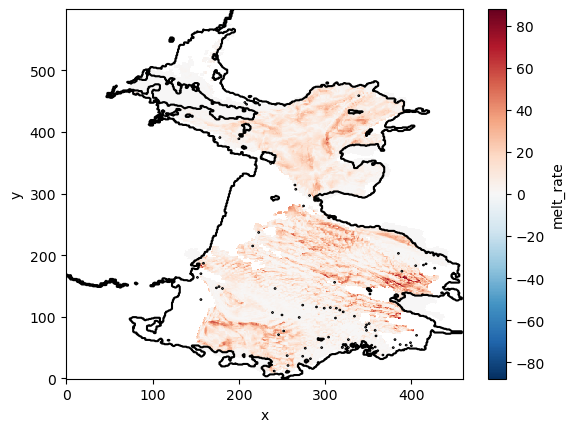

In [16]:
assess_MIT_melt('/g/data/x77/cy8964/mitgcm/archive/original-run-R22_exe')

/jobfs/135207924.gadi-pbs/ipykernel_1607803/438618610.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
[gadi-cpu-bdw-0003.gadi.nci.org.au:1607803] shmem: mmap: an error occurred while determining whether or not /jobfs/135207924.gadi-pbs/ompi.gadi-cpu-bdw-0003.15495/jf.0/429981696/shared_mem_cuda_pool.gadi-cpu-bdw-0003 could be created.
[gadi-cpu-bdw-0003.gadi.nci.org.au:1607803] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Adusumullii lower lobe target 15.144058266891369 m/yr
lower lobe 13.520199829448737 m/yr
full PIG 11.760574510476191 m/yr


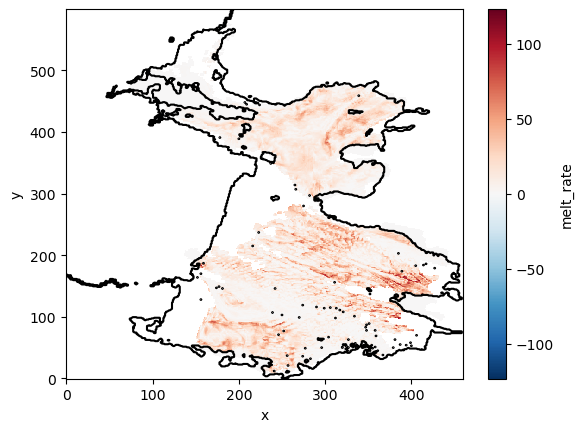

In [11]:
assess_MIT_melt('/scratch/x77/cy8964/gadi_short/cy8964/mitgcm/archive/original-run-R22_exe_tuned')

/jobfs/135246456.gadi-pbs/ipykernel_2592863/438618610.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
[gadi-cpu-bdw-0008.gadi.nci.org.au:2592863] shmem: mmap: an error occurred while determining whether or not /jobfs/135246456.gadi-pbs/ompi.gadi-cpu-bdw-0008.15495/jf.0/2958688256/shared_mem_cuda_pool.gadi-cpu-bdw-0008 could be created.
[gadi-cpu-bdw-0008.gadi.nci.org.au:2592863] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Adusumullii lower lobe target 15.144058266891369 m/yr
lower lobe 15.265971529165832 m/yr
full PIG 13.23447570758776 m/yr


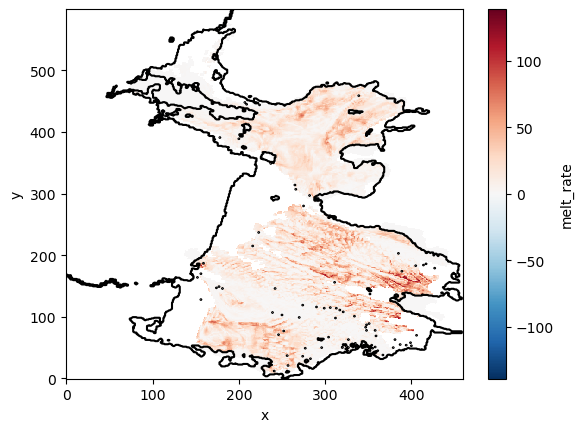

In [7]:
assess_MIT_melt('/scratch/x77/cy8964/gadi_short/cy8964/mitgcm/archive/original-run-R22_exe_tuned2')

/jobfs/135207924.gadi-pbs/ipykernel_1607803/438618610.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Adusumullii lower lobe target 15.144058266891369 m/yr
lower lobe 9.853332667022528 m/yr
full PIG 8.395634759584423 m/yr


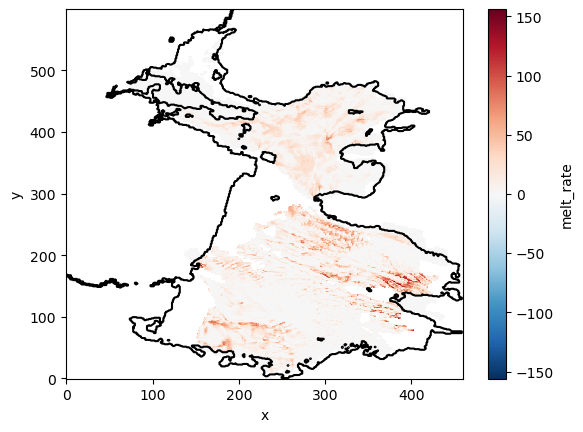

In [17]:
assess_MIT_melt('/g/data/x77/cy8964/mitgcm/archive/run-R22-bigCd-20Aug')

/jobfs/135207924.gadi-pbs/ipykernel_1607803/438618610.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Adusumullii lower lobe target 15.144058266891369 m/yr
lower lobe 17.022518395895524 m/yr
full PIG 13.952785832275273 m/yr


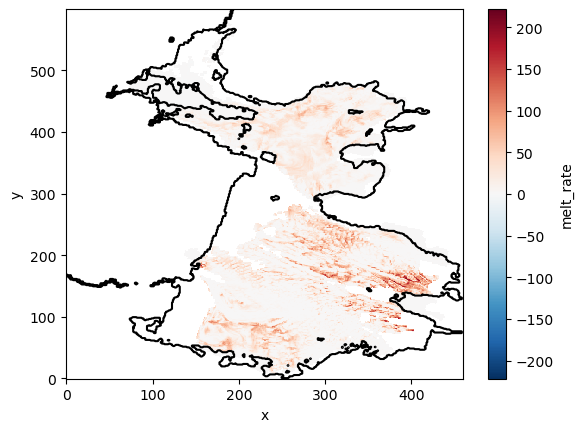

In [14]:
assess_MIT_melt('/scratch/x77/cy8964/gadi_short/cy8964/mitgcm/archive/run-R22-bigCd-20Aug-tuned')

/jobfs/135246456.gadi-pbs/ipykernel_2592863/438618610.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Adusumullii lower lobe target 15.144058266891369 m/yr
lower lobe 14.690128231607117 m/yr
full PIG 12.17648032245781 m/yr


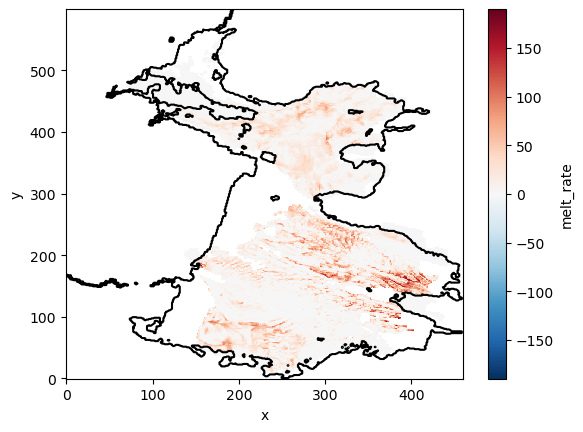

In [8]:
assess_MIT_melt('/scratch/x77/cy8964/gadi_short/cy8964/mitgcm/archive/run-R22-bigCd-20Aug-tuned2')

/jobfs/135269257.gadi-pbs/ipykernel_2160935/438618610.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
[gadi-cpu-bdw-0003.gadi.nci.org.au:2160935] shmem: mmap: an error occurred while determining whether or not /jobfs/135269257.gadi-pbs/ompi.gadi-cpu-bdw-0003.15495/jf.0/2207842304/shared_mem_cuda_pool.gadi-cpu-bdw-0003 could be created.
[gadi-cpu-bdw-0003.gadi.nci.org.au:2160935] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Adusumullii lower lobe target 15.144058266891369 m/yr
lower lobe 15.323377042873803 m/yr
full PIG 12.650891325033905 m/yr


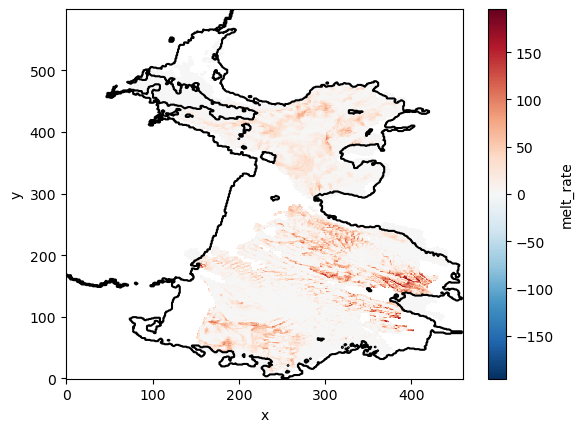

In [7]:
assess_MIT_melt('/scratch/x77/cy8964/gadi_short/cy8964/mitgcm/archive/run-R22-bigCd-20Aug-tuned3')

/jobfs/135207924.gadi-pbs/ipykernel_1607803/438618610.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Adusumullii lower lobe target 15.144058266891369 m/yr
lower lobe 7.472318939837749 m/yr
full PIG 6.215701825670709 m/yr


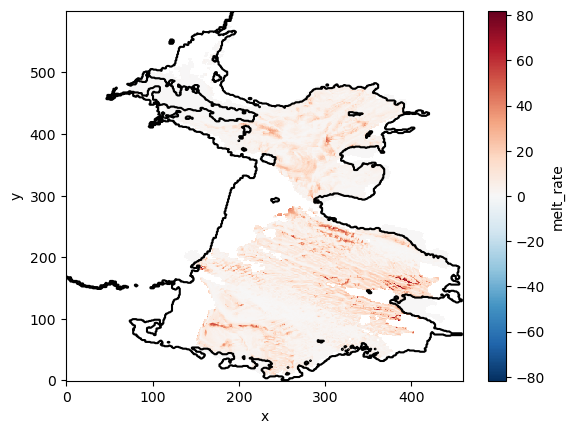

In [18]:
assess_MIT_melt('/g/data/x77/cy8964/mitgcm/archive/run-R22-MK18limlocal')

/jobfs/135207924.gadi-pbs/ipykernel_1607803/438618610.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Adusumullii lower lobe target 15.144058266891369 m/yr
lower lobe 11.975625032357375 m/yr
full PIG 9.931525600726422 m/yr


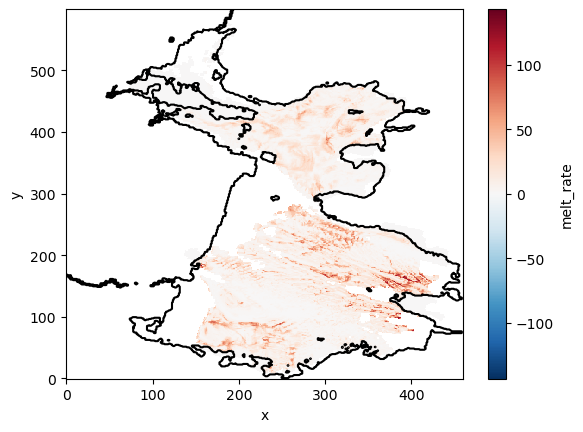

In [15]:
assess_MIT_melt('/scratch/x77/cy8964/gadi_short/cy8964/mitgcm/archive/run-R22-MK18limlocal-tuned')

/jobfs/135246456.gadi-pbs/ipykernel_2592863/438618610.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Adusumullii lower lobe target 15.144058266891369 m/yr
lower lobe 14.840538397902362 m/yr
full PIG 12.204612522689645 m/yr


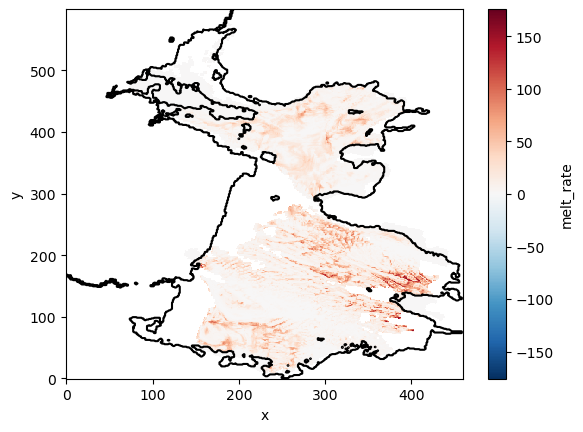

In [9]:
assess_MIT_melt('/scratch/x77/cy8964/gadi_short/cy8964/mitgcm/archive/run-R22-MK18limlocal-tuned2')

/jobfs/135269257.gadi-pbs/ipykernel_2160935/438618610.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Adusumullii lower lobe target 15.144058266891369 m/yr
lower lobe 15.175003864137972 m/yr
full PIG 12.423223401014699 m/yr


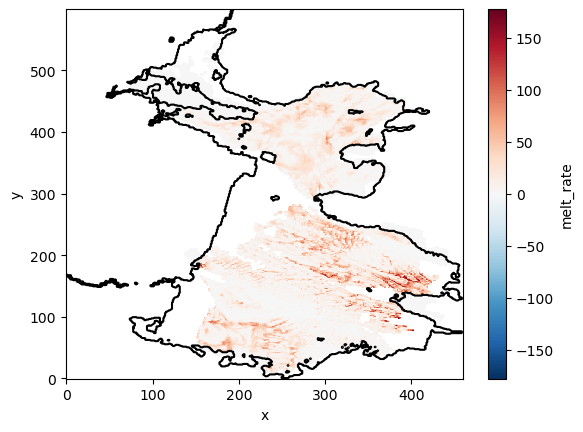

In [8]:
assess_MIT_melt('/scratch/x77/cy8964/gadi_short/cy8964/mitgcm/archive/run-R22-MK18limlocal-tuned3')

/jobfs/135344942.gadi-pbs/ipykernel_2358201/3112063086.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
[gadi-cpu-bdw-0002.gadi.nci.org.au:2358201] shmem: mmap: an error occurred while determining whether or not /jobfs/135344942.gadi-pbs/ompi.gadi-cpu-bdw-0002.15495/jf.0/1514733568/shared_mem_cuda_pool.gadi-cpu-bdw-0002 could be created.
[gadi-cpu-bdw-0002.gadi.nci.org.au:2358201] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Text(0, 0.5, 'mean melt rate (m/yr)')

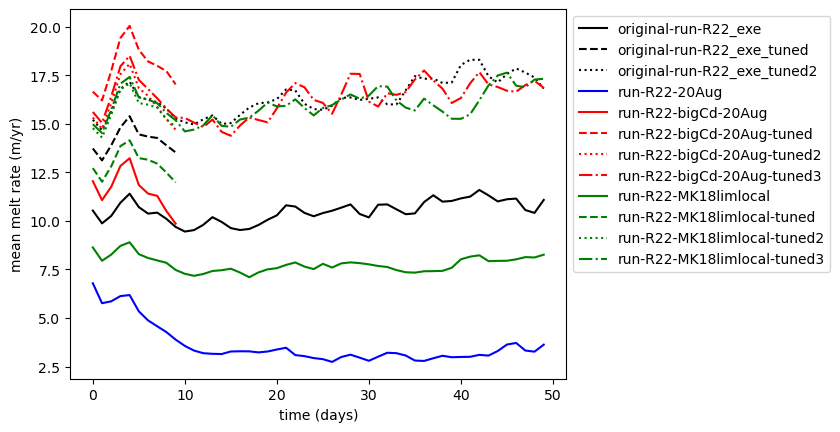

In [7]:
# plot timeseries
dir = '/scratch/x77/cy8964/gadi_short/cy8964/mitgcm/archive/'
names = ['original-run-R22_exe','original-run-R22_exe_tuned','original-run-R22_exe_tuned2',
         'run-R22-20Aug',
         'run-R22-bigCd-20Aug','run-R22-bigCd-20Aug-tuned','run-R22-bigCd-20Aug-tuned2','run-R22-bigCd-20Aug-tuned3',
         'run-R22-MK18limlocal','run-R22-MK18limlocal-tuned','run-R22-MK18limlocal-tuned2','run-R22-MK18limlocal-tuned3']
colors = ['k','k','k',
          'b',
          'r','r','r','r',
          'g','g','g','g']
linestyles = ['-','--','dotted',
              '-',
              '-','--','dotted','-.',
              '-','--','dotted','-.',]
end = '/output000/'
# melt in kg/m^2/s to m/yr = multiply by #seconds per year, divide by rho_0
s_to_yr = 3600*24*365
rho0 = 1000

wb_small = wb[4025:4250,2100:2351]
xs = x_wb[2100:2351]
ys = y_wb[4025:4250]
latxs = np.zeros_like(wb_small)
latys = np.zeros_like(wb_small)
for j in np.arange(len(ys)):
    for i in np.arange(len(xs)):
        latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
ds = xr.Dataset(
    data_vars=dict(
        melt_rate=(["y","x"], wb_small),
    ),
    coords=dict(
        x=("x", np.arange(len(latxs[0,:]))),
        y=("y", np.arange(len(latys[:,0]))),
        lon=(["y","x"], latxs),
        lat=(["y","x"], latys),),
    
    attrs=dict(description="Melt rate"),
)

end = '/output000/'
# melt in kg/m^2/s to m/yr = multiply by #seconds per year, divide by rho_0
s_to_yr = 3600*24*365
rho0 = 1000
dir2 = '/scratch/x77/cy8964/gadi_short/cy8964/mitgcm/archive/run-R22-MK18limlocal-tuned'
XC = mds.rdmds(dir2+end+'XC')
YC = mds.rdmds(dir2+end+'YC')
W = mds.rdmds(dir2+end+'SHICE_fwFlux', 43200)*(-s_to_yr/rho0)
ds_MIT = xr.Dataset(
attrs=dict(description="MItcgm"),
data_vars=dict(
        melt_rate=(["y", "x"], W)),
coords=dict(
    x=("x", np.arange(len(XC[0,:]))),
    y=("y", np.arange(len(YC[:,0]))),
    lat=(["y","x"], YC),
    lon=(["y","x"], XC),
    )
)

ds_out = ds_MIT


regridder = xe.Regridder(ds, ds_out, "bilinear")  #from https://xesmf.readthedocs.io/en/stable/notebooks/Curvilinear_grid.html
dr_out = regridder(ds,skipna=True)

for i in np.arange(len(names)):
    XC = mds.rdmds(dir+names[i]+end+'XC')
    YC = mds.rdmds(dir+names[i]+end+'YC')
    melt_arr = np.zeros(50)
    for k in np.arange(5):
        for j in np.arange(10):
            time = np.arange(4320*(10*k+1),43201*(20*(k+1)),4320)[j]
            try:
                W = mds.rdmds(dir+names[i]+'/output00'+str(k)+'/'+'SHICE_fwFlux', time)*(-s_to_yr)/rho0

                ds_MIT = xr.Dataset(
                attrs=dict(description="MItcgm"),
                data_vars=dict(
                        melt_rate=(["y", "x"], W)),
                coords=dict(
                    x=("x", np.arange(len(XC[0,:]))),
                    y=("y", np.arange(len(YC[:,0]))),
                    lat=(["y","x"], YC),
                    lon=(["y","x"], XC),
                    )
                )
                melt_arr[k*10+j]=ds_MIT.melt_rate.where(dr_out.melt_rate <1e36).where(ds_MIT.lat<-74.86).mean().values
            except:
                melt_arr[k*10+j] = np.NaN #print('no data for days ',time)
    # for j in np.arange(10):
    #     time = np.arange(4320,43201,4320)[j]
    #     W = mds.rdmds(dir+names[i]+'/output000/'+'SHICE_fwFlux', time)*(-s_to_yr)/rho0
    #     melt_arr[j] = W[W!=0].mean()
    # for j in np.arange(10):
    #     time = np.arange(47520,86401,4320)[j]
    #     W = mds.rdmds(dir+names[i]+'/output001/'+'SHICE_fwFlux', time)*(-s_to_yr)/rho0
    #     melt_arr[j+10] = W[W!=0].mean()
    plt.plot(np.arange(50),melt_arr,label = names[i],color = colors[i], linestyle = linestyles[i])
plt.legend(bbox_to_anchor = (1,1),loc = 'upper left')
plt.xlabel('time (days)')
plt.ylabel('mean melt rate (m/yr)')


In [11]:
def diff_obs_MIT_melt(dir):
    # first compute Adusumilli PIG mask
    wb_small = wb[4025:4250,2100:2351]
    xs = x_wb[2100:2351]
    ys = y_wb[4025:4250]
    latxs = np.zeros_like(wb_small)
    latys = np.zeros_like(wb_small)
    for j in np.arange(len(ys)):
        for i in np.arange(len(xs)):
            latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
    ds = xr.Dataset(
        data_vars=dict(
            melt_rate=(["y","x"], wb_small),
        ),
        coords=dict(
            x=("x", np.arange(len(latxs[0,:]))),
            y=("y", np.arange(len(latys[:,0]))),
            lon=(["y","x"], latxs),
            lat=(["y","x"], latys),),
        
        attrs=dict(description="Melt rate"),
    )
    # open MITgcm grid and data
    #open MITgcm output
    
    end = '/output000/'
    # melt in kg/m^2/s to m/yr = multiply by #seconds per year, divide by rho_0
    s_to_yr = 3600*24*365
    rho0 = 1000
        
    XC = mds.rdmds(dir+end+'XC')
    YC = mds.rdmds(dir+end+'YC')
    W = mds.rdmds(dir+end+'SHICE_fwFlux', 43200)*(-s_to_yr/rho0)
    ds_MIT = xr.Dataset(
    attrs=dict(description="MItcgm"),
    data_vars=dict(
            melt_rate=(["y", "x"], W)),
    coords=dict(
        x=("x", np.arange(len(XC[0,:]))),
        y=("y", np.arange(len(YC[:,0]))),
        lat=(["y","x"], YC),
        lon=(["y","x"], XC),
        )
    )
    
    ds_out = ds_MIT
    # regrid onto MITgcm grid
    regridder = xe.Regridder(ds, ds_out, "bilinear")  #from https://xesmf.readthedocs.io/en/stable/notebooks/Curvilinear_grid.html
    dr_out = regridder(ds,skipna=True)

    (ds_MIT.melt_rate.where(dr_out.melt_rate <1e36)-dr_out.melt_rate.where(ds_MIT.melt_rate!=0)).plot(vmax = 80, vmin = -80, cmap= 'RdBu_r')
    print('Adusumullii lower lobe target',dr_out.melt_rate.where(dr_out.lat<-74.86).mean().values, 'm/yr')
    print('lower lobe', ds_MIT.melt_rate.where(dr_out.melt_rate <1e36).where(ds_MIT.lat<-74.86).mean().values, 'm/yr')
    print('full PIG', ds_MIT.melt_rate.where(dr_out.melt_rate <1e36).mean().values, 'm/yr')
    
    (ds_MIT.melt_rate.where(ds_MIT.melt_rate!=0)*0+1).fillna(0).plot.contour(levels = [0.5], colors = 'k')
    RMS = np.sqrt(((ds_MIT.melt_rate.where(dr_out.melt_rate <1e36).where(ds_MIT.melt_rate !=0) - 
            dr_out.melt_rate.where(dr_out.melt_rate <1e36).where(ds_MIT.melt_rate !=0))**2).mean().values)
    print('RMS', RMS)
    plt.show()

/jobfs/135615524.gadi-pbs/ipykernel_3703629/93987476.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Adusumullii lower lobe target 15.144058266891369 m/yr
lower lobe 15.265971529165832 m/yr
full PIG 13.23447570758776 m/yr
RMS 17.233932841579893


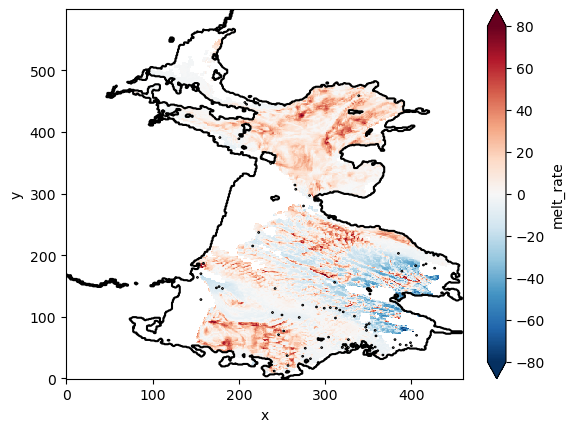

/jobfs/135615524.gadi-pbs/ipykernel_3703629/93987476.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Adusumullii lower lobe target 15.144058266891369 m/yr
lower lobe 15.323377042873803 m/yr
full PIG 12.650891325033905 m/yr
RMS 20.779792260759724


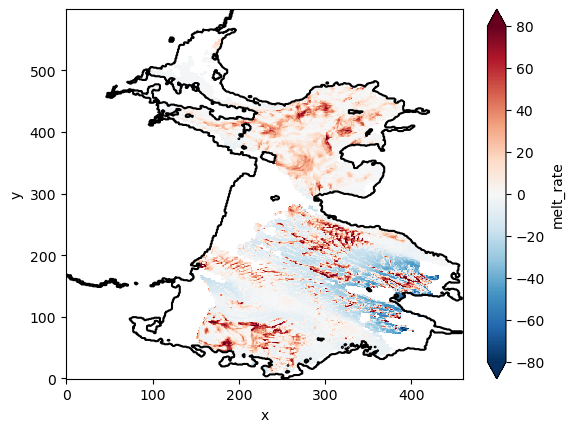

/jobfs/135615524.gadi-pbs/ipykernel_3703629/93987476.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  latys[j,i],latxs[j,i] = transformer.transform(xs[i],ys[j])
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Adusumullii lower lobe target 15.144058266891369 m/yr
lower lobe 15.175003864137972 m/yr
full PIG 12.423223401014699 m/yr
RMS 18.070671845930253


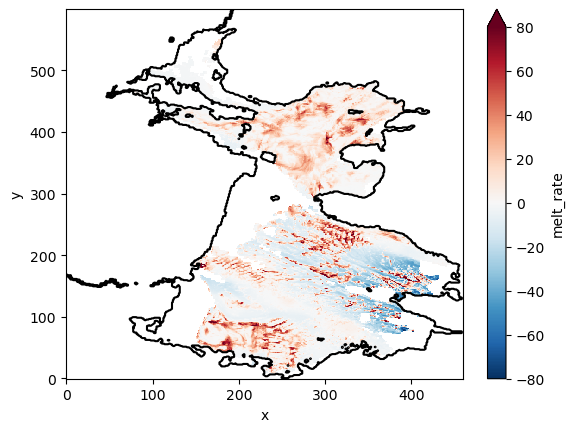

In [12]:
diff_obs_MIT_melt('/scratch/x77/cy8964/gadi_short/cy8964/mitgcm/archive/original-run-R22_exe_tuned2')
diff_obs_MIT_melt('/scratch/x77/cy8964/gadi_short/cy8964/mitgcm/archive/run-R22-bigCd-20Aug-tuned3')
diff_obs_MIT_melt('/scratch/x77/cy8964/gadi_short/cy8964/mitgcm/archive/run-R22-MK18limlocal-tuned3')
